# Portfolio Optimization Thesis

**Author:** Jean Jacques Kamdem  
**Matrikelnummer:** 548153  

**Topic:** Portfolio Optimization using Machine Learning and Volatility Models  

---

## Description

This notebook is part of a structured project investigating portfolio optimization.

It focuses on:
- Simulation of portfolios
- Efficient frontier visualization

---

# Markowitz Portfolio Optimization

In diesem Notebook wird die klassische Portfoliooptimierung nach Markowitz implementiert.

## Theorie

Gegeben sind:

- μ: erwartete Renditen
- Σ: Kovarianzmatrix

Ziel ist es, ein Portfolio mit optimalem Verhältnis zwischen Rendite und Risiko zu finden.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [2]:
np.random.seed(42)

returns = pd.DataFrame({
    "Asset_A": np.random.normal(0.001, 0.02, 100),
    "Asset_B": np.random.normal(0.001, 0.015, 100)
})

In [3]:
mu = returns.mean()
sigma = returns.cov()

mu, sigma

(Asset_A   -0.001077
 Asset_B    0.001335
 dtype: float64,
           Asset_A   Asset_B
 Asset_A  0.000330 -0.000035
 Asset_B -0.000035  0.000205)

## Portfolio-Gewichte

Die Gewichte bestimmen, wie viel Kapital in jeden Vermögenswert investiert wird.

Die Summe der Gewichte ist gleich 1.


In [4]:
weights = np.array([0.5, 0.5])

Die Gewichte sind hier gleich verteilt (50% / 50%).

## Portfolio-Rendite

Die erwartete Rendite des Portfolios wird berechnet als:

Rp = w^T * μ

In [5]:
portfolio_return = np.dot(weights, mu)
portfolio_return

np.float64(0.00012881922893349061)

Die Portfolio-Rendite ist eine gewichtete Summe der erwarteten Renditen.

## Portfolio-Risiko

Das Risiko wird durch die Varianz gemessen:

σ² = w^T Σ w

In [6]:
portfolio_variance = np.dot(weights.T, np.dot(sigma, weights))
portfolio_variance

np.float64(0.0001159123633968576)

## Volatilität

Die Volatilität ist die Quadratwurzel der Varianz.

In [7]:
portfolio_volatility = np.sqrt(portfolio_variance)
portfolio_volatility

np.float64(0.010766260418402371)

## Efficient Frontier

In diesem Abschnitt werden viele zufällige Portfolios generiert.

Jedes Portfolio hat unterschiedliche Gewichte, die zufällig erzeugt werden.

Für jedes Portfolio berechnen wir:

- die erwartete Rendite
- das Risiko (Volatilität)

Ziel ist es, die Beziehung zwischen Risiko und Rendite zu analysieren.

In [8]:
# Listen zur Speicherung der Ergebnisse
weights_list = []
returns_list = []
risk_list = []

# Simulation von 1000 Portfolios
for i in range(1000):

    # Zufällige Gewichte erzeugen
    weights = np.random.random(2)

    # Gewichte normalisieren (Summe = 1)
    weights = weights / np.sum(weights)

    # Gewichte speichern
    weights_list.append(weights)

    # Portfolio-Rendite berechnen
    port_return = np.dot(weights, mu)
    returns_list.append(port_return)

    # Portfolio-Risiko berechnen (Varianz)
    port_var = np.dot(weights.T, np.dot(sigma, weights))

    # Volatilität (Wurzel der Varianz)
    port_vol = np.sqrt(port_var)
    risk_list.append(port_vol)

## Visualisierung der Efficient Frontier

Die simulierten Portfolios werden in einem Risiko-Rendite-Diagramm dargestellt.

Jeder Punkt entspricht einem Portfolio mit bestimmten Gewichten.

- X-Achse: Risiko (Volatilität)
- Y-Achse: erwartete Rendite

Die obere Grenze der Punkte stellt die sogenannte effiziente Frontier dar.

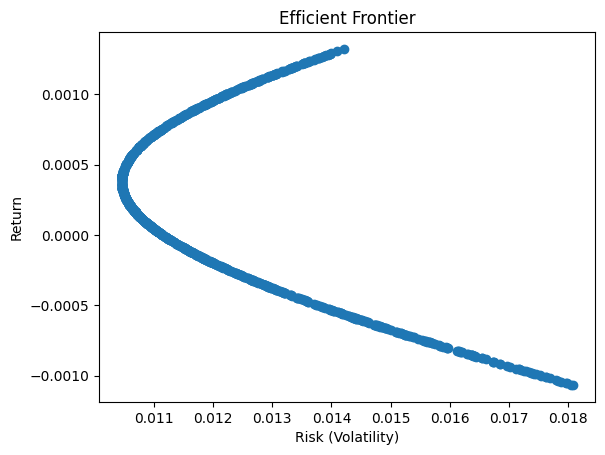

In [9]:
plt.scatter(risk_list, returns_list)

plt.xlabel("Risk (Volatility)")
plt.ylabel("Return")

plt.title("Efficient Frontier")

plt.show()

## Interpretation

Man erkennt, dass einige Portfolios bei gleichem Risiko eine höhere Rendite bieten als andere.

Die obere Grenze dieser Punkte stellt die effiziente Frontier dar.

Diese Portfolios sind optimal, da sie die maximale Rendite für ein gegebenes Risiko liefern.

## Sharpe Ratio

Der Sharpe Ratio misst die Rendite pro Risikoeinheit.

Formel:

S = (Rp - Rf) / σp

Ein höherer Sharpe Ratio bedeutet ein besseres Portfolio.

In [10]:
# Risikofreier Zinssatz (vereinfachend = 0)
rf = 0

sharpe_list = []

for i in range(len(returns_list)):
    
    sharpe = (returns_list[i] - rf) / risk_list[i]
    sharpe_list.append(sharpe)

# Index des besten Portfolios
max_sharpe_idx = np.argmax(sharpe_list)

# Bestes Portfolio
best_return = returns_list[max_sharpe_idx]
best_risk = risk_list[max_sharpe_idx]

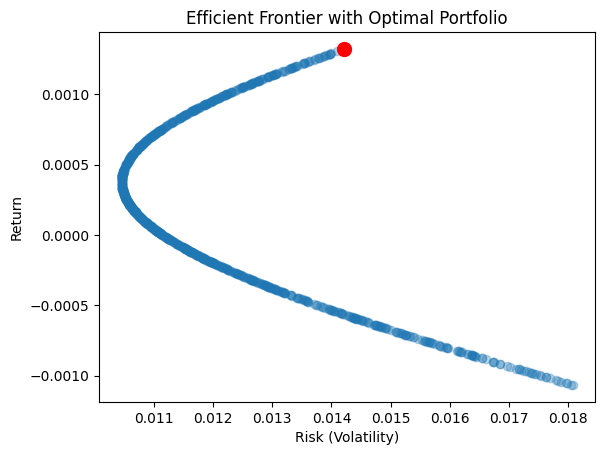

In [11]:
plt.scatter(risk_list, returns_list, alpha=0.3)

# meilleur portefeuille en rouge
plt.scatter(best_risk, best_return, color='red', s=100)

plt.xlabel("Risk (Volatility)")
plt.ylabel("Return")
plt.title("Efficient Frontier with Optimal Portfolio")

plt.show()

## Optimales Portfolio

Das rote Punkt stellt das Portfolio mit dem höchsten Sharpe Ratio dar.

Dieses Portfolio bietet das beste Verhältnis zwischen Rendite und Risiko.